In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
sentences = ['cat chases mouse',
        'cat catches mouse',
        'cat eats mouse',
        'mouse runs into hole',
        'cat says bad words',
        'cat and mouse are pals',
        'cat and mouse are chums',
        'mouse stores food in hole',
        'cat stores food in house',
        'mouse sleeps in hole',
        'cat sleeps in0000 house',
        'cat and mouse are buddies',
        'mouse lives in hole',
        'cat lives in house']

In [ ]:
def get_vocab(data):
  i = 1
  word2idx = dict()
  idx2word = {0: '<PAD>'}
  temp = set()

  for sentence in sentences:
    for word in sentence.split():
      if word not in temp:
        temp.add(word)
        word2idx[word] = i
        idx2word[i] = word
        i += 1
  return i, word2idx, idx2word

vocab_size, word2idx, idx2word = get_vocab(sentences)

In [ ]:
vocab_size

23

In [ ]:
word2idx['eats']

5

In [ ]:
word2idx['mouse'], idx2word[3]

(3, 'mouse')

In [ ]:
def prev_words(i, doc, window_size):
  out = []
  for index in range(i-window_size, i):
    if index >= 0:
      out.append(word2idx[doc[index]])
    else:
      out.append(0) # 0 = <PAD>
  return out

def next_words(i, doc, window_size):
  out = []
  for index in range(i+1, i+window_size+1, 1):
    if index < len(doc):
      out.append(word2idx[doc[index]])
    else:
      out.append(0) # 0 = <PAD>
  return out


def get_training_data(sentences, window_size=6):
  X = []
  y = []
  for sentence in sentences:
    xi = []
    yi = []
    sentence = sentence.split()
    for index, word in enumerate(sentence):
      prev = prev_words(index, sentence, window_size//2)
      next = next_words(index, sentence, window_size//2)
      assert len(prev) == len(next)
      xi.append(prev + next)
      yi.append([word2idx[word]])
    X.extend(xi)
    y.extend(yi)
  return X, y

window_size = 6
X, y = get_training_data(sentences, window_size)

In [ ]:
import numpy as np

X = np.array(X)
[idx2word[i] for i in X[24]]

['<PAD>', 'cat', 'and', 'are', 'chums', '<PAD>']

In [ ]:
[idx2word[i] for i in y[24]]

['mouse']

In [ ]:
len(X)

58

In [ ]:
model = tf.keras.models.Sequential()

In [ ]:
embed_size = 2
model.add(tf.keras.layers.Embedding(vocab_size, embed_size,
                                    input_length=6, name='embedding'))
model.add(tf.keras.layers.GlobalAveragePooling1D())
model.add(tf.keras.layers.Dense(vocab_size,
                                activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy')

In [ ]:
import numpy as np

X = np.array(X)
y = np.array(y)

model.fit(X, y, epochs=10, batch_size=6)

NameError: name 'X' is not defined

In [ ]:
word = 'mouse'
input_vec = tf.convert_to_tensor([word2idx[word]])
model.get_layer('embedding')(input_vec).numpy().tolist()

[[-0.030933232977986336, 0.09404587000608444]]

In [ ]:
word2vec = []
for word, word_index  in word2idx.items():
  input_vec = tf.convert_to_tensor([word2idx[word]])
  emb = model.get_layer('embedding')(input_vec).numpy().tolist()[0]
  word2vec.append((word, emb))

In [ ]:
word2vec[11]

('and', [0.014986240305006504, -0.028829798102378845])

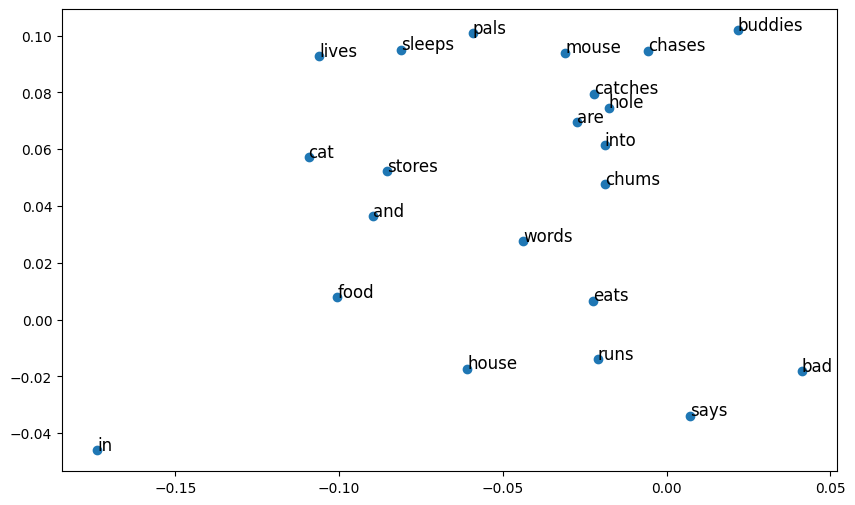

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter([i[1][0] for i in word2vec], [i[1][1] for i in word2vec])
for item in word2vec:
  word = item[0]
  plt.text(item[1][0], item[1][1], word, fontdict={'fontsize':12})
plt.show()

I love cats
she dislikes rain in winter
length=6
I love cats <pad> <pad> <pad> [1 2 3 0 0 0]
She dislikes rain in winter <pad>[4 5 6 7 8 0]



The cat sat
the dog barked

vocab_size=7(6+1)
idx2word={0:<pad>,